### LOAN PREDICTION

### Data Dictionary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('LoansTrainingSet.csv')

### 1.EDA and Data Cleaning

In [3]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [4]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Years in current job', 'Home Ownership',
       'Annual Income', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='str')

In [5]:
df.shape

(256984, 19)

In [6]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     61676
Years in current job             11476
Home Ownership                       0
Annual Income                    61676
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    140383
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       529
Tax Liens                           23
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(16610)

In [8]:
df[df.duplicated(keep=False)].head(20)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
13,00029f9f-0cc5-4d4e-aabc-ea4a7fe74e12,afbc2fa3-3bad-4d48-b691-829aed78bad5,Charged Off,17961,Short Term,701.0,< 1 year,Own Home,53053.0,Debt Consolidation,$596.85,9.9,43.0,7,0,6810,22775,0.0,0.0
14,00029f9f-0cc5-4d4e-aabc-ea4a7fe74e12,afbc2fa3-3bad-4d48-b691-829aed78bad5,Charged Off,17961,Short Term,701.0,< 1 year,Own Home,53053.0,Debt Consolidation,$596.85,9.9,43.0,7,0,6810,22775,0.0,0.0
18,00035328-2636-4390-8322-5841de482d2b,28eb75ac-6a09-4057-b73f-726c72ebf933,Charged Off,11604,Short Term,729.0,6 years,Home Mortgage,35315.0,Debt Consolidation,$662.16,15.0,NaN,12,0,17092,20743,0.0,0.0
19,00035328-2636-4390-8322-5841de482d2b,28eb75ac-6a09-4057-b73f-726c72ebf933,Charged Off,11604,Short Term,729.0,6 years,Home Mortgage,35315.0,Debt Consolidation,$662.16,15.0,NaN,12,0,17092,20743,0.0,0.0
31,0006572c-9567-484d-b49b-bfe06536aa96,c1a7ba66-9f36-4f5c-86cd-1aa7ad68b954,Charged Off,14727,Short Term,740.0,3 years,Home Mortgage,70690.0,Debt Consolidation,"$1,083.91",18.0,27.0,12,0,43375,225911,0.0,0.0
32,0006572c-9567-484d-b49b-bfe06536aa96,c1a7ba66-9f36-4f5c-86cd-1aa7ad68b954,Charged Off,14727,Short Term,740.0,3 years,Home Mortgage,70690.0,Debt Consolidation,"$1,083.91",18.0,27.0,12,0,43375,225911,0.0,0.0
36,000795b0-d767-42bf-837a-80d5b78c1e50,b533c78c-3096-4914-acb1-5453c0ff76a4,Charged Off,19731,Long Term,623.0,3 years,Rent,43846.0,Buy House,$738.08,16.2,55.0,13,1,9031,17955,1.0,0.0
37,000795b0-d767-42bf-837a-80d5b78c1e50,b533c78c-3096-4914-acb1-5453c0ff76a4,Charged Off,19731,Long Term,623.0,3 years,Rent,43846.0,Buy House,$738.08,16.2,55.0,13,1,9031,17955,1.0,0.0
39,0008a65c-3054-4b5d-931d-8352021f813d,04513d99-d809-4eb6-b4bb-6abc767d861e,Charged Off,7066,Short Term,741.0,10+ years,Own Home,60564.0,Debt Consolidation,$706.58,14.6,56.0,4,0,6229,9242,0.0,0.0
40,0008a65c-3054-4b5d-931d-8352021f813d,04513d99-d809-4eb6-b4bb-6abc767d861e,Charged Off,7066,Short Term,741.0,10+ years,Own Home,60564.0,Debt Consolidation,$706.58,14.6,56.0,4,0,6229,9242,0.0,0.0


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df[df.duplicated(keep=False)].head(20)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens


In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
df.shape

(240374, 19)

In [13]:
print(len(df))
print(df['Loan ID'].nunique())

240374
215700


In [14]:
df['n_missing'] = df.isna().sum(axis=1)
df = (df.sort_values('n_missing')
        .drop_duplicates(subset='Loan ID', keep='first')
        .drop(columns='n_missing')
        .reset_index(drop=True))


In [15]:
df.shape

(215700, 19)

In [16]:
df['Home Ownership'].unique()

<StringArray>
['Rent', 'Home Mortgage', 'Own Home', 'HaveMortgage']
Length: 4, dtype: str

In [17]:
df['Home Ownership'].value_counts()

Home Ownership
Home Mortgage    106492
Rent              89619
Own Home          19094
HaveMortgage        495
Name: count, dtype: int64

In [18]:
df['Home Ownership'] = df['Home Ownership'].replace('HaveMortgage', 'Home Mortgage')

In [19]:
df['Home Ownership'].value_counts()

Home Ownership
Home Mortgage    106987
Rent              89619
Own Home          19094
Name: count, dtype: int64

In [20]:
df['Loan Status'].value_counts()

Loan Status
Fully Paid     176191
Charged Off     39509
Name: count, dtype: int64

In [21]:
df['Loan Status'].unique()

<StringArray>
['Fully Paid', 'Charged Off']
Length: 2, dtype: str

In [22]:
df['Term'].unique()

<StringArray>
['Short Term', 'Long Term']
Length: 2, dtype: str

In [23]:
df['Term'].value_counts()

Term
Short Term    166523
Long Term      49177
Name: count, dtype: int64

In [24]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     44498
Years in current job              8990
Home Ownership                       0
Annual Income                    44498
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    118262
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       452
Tax Liens                           22
dtype: int64

In [25]:
df['Years in current job'].value_counts(dropna=False)

Years in current job
10+ years    66711
2 years      19831
< 1 year     17544
3 years      17428
5 years      14987
1 year       14130
4 years      13632
6 years      12230
7 years      11713
8 years      10232
NaN           8990
9 years       8272
Name: count, dtype: int64

In [26]:
df['Purpose'].value_counts(dropna=False)

Purpose
Debt Consolidation      171096
Home Improvements        12840
other                    11726
Other                     8281
Business Loan             3611
Buy a Car                 2926
Medical Bills             2375
Take a Trip               1312
Buy House                 1308
Educational Expenses       225
Name: count, dtype: int64

In [27]:
df['Purpose'] = df['Purpose'].replace('other', 'Other')

In [28]:
df['Purpose'].value_counts(dropna=False)

Purpose
Debt Consolidation      171096
Other                    20007
Home Improvements        12840
Business Loan             3611
Buy a Car                 2926
Medical Bills             2375
Take a Trip               1312
Buy House                 1308
Educational Expenses       225
Name: count, dtype: int64

In [29]:
df["Credit Score"].describe()

count    171202.000000
mean        969.146797
std        1230.129015
min         585.000000
25%         714.000000
50%         733.000000
75%         743.000000
max        7510.000000
Name: Credit Score, dtype: float64

In [30]:
(df["Credit Score"] > 800).sum()

np.int64(6597)

In [31]:
df.loc[df["Credit Score"] > 800, "Credit Score"].value_counts().sort_index()

Credit Score
5850.0     2
5860.0     1
5870.0     2
5880.0     1
5890.0     1
          ..
7470.0    85
7480.0    68
7490.0    23
7500.0    38
7510.0    17
Name: count, Length: 164, dtype: int64

In [32]:
df.loc[df["Credit Score"] > 800, "Credit Score"] = (df.loc[df["Credit Score"] > 800, "Credit Score"] / 10)

In [33]:
df["Credit Score"].describe()

count    171202.000000
mean        722.755698
std          26.827283
min         585.000000
25%         712.000000
50%         732.000000
75%         742.000000
max         751.000000
Name: Credit Score, dtype: float64

In [34]:
df["Annual Income"].describe()

count    1.712020e+05
mean     7.280452e+04
std      5.730498e+04
min      0.000000e+00
25%      4.476600e+04
50%      6.210500e+04
75%      8.779425e+04
max      8.713547e+06
Name: Annual Income, dtype: float64

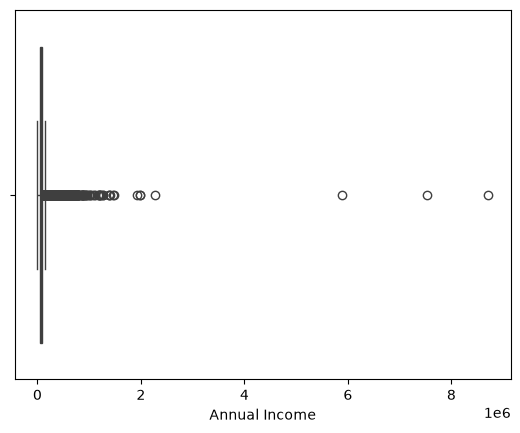

In [35]:
sns.boxplot(x=df["Annual Income"])
plt.show()

In [36]:
cols = [
    "Current Loan Amount",
    "Monthly Debt",
    "Years of Credit History",
    "Number of Open Accounts",
    "Number of Credit Problems",
    "Current Credit Balance",
    "Maximum Open Credit"
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,215700.0,1.633515e+07,3.695307e+07,505.0,8328.0,14642.0,25208.00,99999999.0
Years of Credit History,215700.0,1.835976e+01,7.057999e+00,3.4,13.6,17.0,21.80,70.5
Number of Open Accounts,215700.0,1.107757e+01,4.971825e+00,0.0,8.0,10.0,14.00,76.0
Number of Credit Problems,215700.0,1.554242e-01,4.579723e-01,0.0,0.0,0.0,0.00,11.0
Current Credit Balance,215700.0,1.545723e+04,1.975046e+04,0.0,5932.0,11042.0,19324.25,1731412.0


In [37]:
(df['Current Loan Amount'] == 99999999).sum()

np.int64(35210)

In [38]:
pd.crosstab( df["Current Loan Amount"] == 99999999,df["Loan Status"],normalize="index") * 100

Loan Status,Charged Off,Fully Paid
Current Loan Amount,,
False,21.889855,78.110145
True,0.000000,100.000000


In [39]:
df['Current Loan Amount'] = df['Current Loan Amount'].replace(99999999, np.nan)

In [40]:
df['Monthly Debt'].dtype

<StringDtype(storage='python', na_value=nan)>

In [41]:
df['Monthly Debt'].head(10)

0    $1,497.79 
1       $860.61
2        $87.41
3    $1,017.33 
4    $2,333.65 
5    $1,646.04 
6    $1,056.84 
7       $981.68
8    $2,613.69 
9       $327.85
Name: Monthly Debt, dtype: str

In [42]:
df['Monthly Debt']=(
    df['Monthly Debt'].str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .astype(float)
)

In [43]:
df['Monthly Debt'].head(10)

0    1497.79
1     860.61
2      87.41
3    1017.33
4    2333.65
5    1646.04
6    1056.84
7     981.68
8    2613.69
9     327.85
Name: Monthly Debt, dtype: float64

In [44]:
cols = [
    "Current Loan Amount",
    "Monthly Debt",
    "Years of Credit History",
    "Number of Open Accounts",
    "Number of Credit Problems",
    "Current Credit Balance",
    "Maximum Open Credit"
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,180490.0,13806.599900,8215.189850,505.0,7604.00,11966.500,19055.75,41000.00
Monthly Debt,215700.0,960.395533,634.780469,0.0,527.65,840.545,1249.91,22939.12
Years of Credit History,215700.0,18.359758,7.057999,3.4,13.60,17.000,21.80,70.50
Number of Open Accounts,215700.0,11.077566,4.971825,0.0,8.00,10.000,14.00,76.00
Number of Credit Problems,215700.0,0.155424,0.457972,0.0,0.00,0.000,0.00,11.00
Current Credit Balance,215700.0,15457.231701,19750.461796,0.0,5932.00,11042.000,19324.25,1731412.00


In [45]:
df['Maximum Open Credit'].dtype

dtype('O')

In [46]:
df['Maximum Open Credit'].head(10)

0    26843
1    29065
2     2445
3     2971
4    59356
5    14906
6    23125
7    16458
8    10420
9    14508
Name: Maximum Open Credit, dtype: object

In [47]:
df['Maximum Open Credit'] = pd.to_numeric(df['Maximum Open Credit'], errors="coerce")

In [48]:
df['Maximum Open Credit'].dtype

dtype('float64')

In [49]:
cols = [
    "Current Loan Amount",
    "Monthly Debt",
    "Years of Credit History",
    "Number of Open Accounts",
    "Number of Credit Problems",
    "Current Credit Balance",
    "Maximum Open Credit"
]

df[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,180490.0,13806.599900,8215.189850,505.0,7604.00,11966.500,19055.75,4.100000e+04
Monthly Debt,215700.0,960.395533,634.780469,0.0,527.65,840.545,1249.91,2.293912e+04
Years of Credit History,215700.0,18.359758,7.057999,3.4,13.60,17.000,21.80,7.050000e+01
Number of Open Accounts,215700.0,11.077566,4.971825,0.0,8.00,10.000,14.00,7.600000e+01
Number of Credit Problems,215700.0,0.155424,0.457972,0.0,0.00,0.000,0.00,1.100000e+01
Current Credit Balance,215700.0,15457.231701,19750.461796,0.0,5932.00,11042.000,19324.25,1.731412e+06
Maximum Open Credit,215698.0,36983.860787,601180.478448,0.0,12961.00,22060.000,36810.00,1.763322e+08


In [50]:
df.isnull().sum()[df.isnull().sum() > 0]

Current Loan Amount              35210
Credit Score                     44498
Years in current job              8990
Annual Income                    44498
Months since last delinquent    118262
Maximum Open Credit                  2
Bankruptcies                       452
Tax Liens                           22
dtype: int64

In [51]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,52f6090e-0fea-4f48-9de9-c273384b8f74,52946ab9-f8a4-4e43-b081-9a36cd55beb7,Fully Paid,20332.0,Short Term,740.0,< 1 year,Rent,81328.0,Debt Consolidation,1497.79,15.0,75.0,21,0,15193,26843.0,0.0,0.0
1,52f5c87d-987a-4f71-88e2-c23ad6330fe2,b6e3c95e-5514-4c48-9e55-6a0fdfab0f94,Fully Paid,23303.0,Short Term,713.0,10+ years,Home Mortgage,103273.0,Debt Consolidation,860.61,26.0,43.0,14,1,14387,29065.0,0.0,0.0
2,52f5b0c0-6892-402b-b87b-9979af016a32,f6bac330-18bd-4dc2-8708-0feb5ec2a616,Fully Paid,9775.0,Short Term,652.0,2 years,Home Mortgage,180838.0,Other,87.41,28.3,25.0,3,0,2391,2445.0,0.0,0.0
3,52f4ae2c-feb1-4a9f-9b4d-114183f3f19d,4f82ec05-afc6-4089-8f6c-25105048603a,Charged Off,5549.0,Short Term,684.0,< 1 year,Home Mortgage,69363.0,Home Improvements,1017.33,15.5,56.0,10,1,1786,2971.0,1.0,0.0
4,52f40a3b-34ca-495c-9da2-75bd2b2617f3,5908ad2b-6eef-4a18-9cfd-7253c5c9e49e,Fully Paid,10161.0,Short Term,705.0,4 years,Home Mortgage,105674.0,Debt Consolidation,2333.65,17.5,48.0,25,0,30568,59356.0,0.0,0.0


In [52]:
print(df["Bankruptcies"].value_counts(dropna=False))
print()

print(df["Tax Liens"].value_counts(dropna=False))



Bankruptcies
0.0    192727
1.0     21506
2.0       818
NaN       452
3.0       155
4.0        25
5.0        13
6.0         3
7.0         1
Name: count, dtype: int64

Tax Liens
0.0     211881
1.0       2701
2.0        707
3.0        195
4.0         97
5.0         48
6.0         26
NaN         22
8.0          7
7.0          6
9.0          5
10.0         3
11.0         2
Name: count, dtype: int64


In [53]:
df[["Bankruptcies", "Tax Liens"]] = df[["Bankruptcies", "Tax Liens"]].fillna(0)

In [54]:
df[["Bankruptcies", "Tax Liens"]].isnull().sum()

Bankruptcies    0
Tax Liens       0
dtype: int64

In [55]:
df[["Maximum Open Credit"]].describe()

,Maximum Open Credit
count,2.156980e+05
mean,3.698386e+04
std,6.011805e+05
min,0.000000e+00
25%,1.296100e+04
50%,2.206000e+04
75%,3.681000e+04
max,1.763322e+08


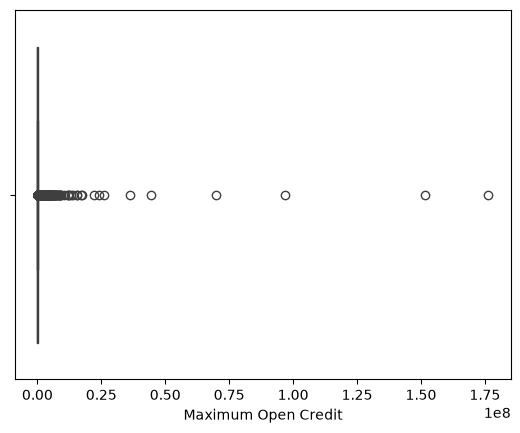

In [56]:
sns.boxplot(x=df['Maximum Open Credit'])
plt.show();

In [57]:
df["Maximum Open Credit"] = df["Maximum Open Credit"].fillna(df["Maximum Open Credit"].median())

In [58]:
df['Maximum Open Credit'].isnull().sum()

np.int64(0)

### 2. Variables with large missing values

In [59]:
df.isnull().sum()[df.isnull().sum() > 0]

Current Loan Amount              35210
Credit Score                     44498
Years in current job              8990
Annual Income                    44498
Months since last delinquent    118262
dtype: int64

#### 2.1. 'Months since last delinquent' Variable

In [60]:
df[['Months since last delinquent']].head()

,Months since last delinquent
0,75.0
1,43.0
2,25.0
3,56.0
4,48.0


In [61]:
multi = df.groupby('Customer ID')['Months since last delinquent'] \
          .agg(lambda s: s.isna().nunique())   # 2 = mixed NaN/non-NaN
print((multi == 2).sum(), "customers with inconsistent missingness")

0 customers with inconsistent missingness


In [62]:
print((df['Customer ID'].value_counts() > 1).sum(), "customers with >1 loan")

0 customers with >1 loan


In [63]:
sub = df[df['Customer ID'].map(df['Customer ID'].value_counts()) > 1]
print((sub.groupby('Customer ID')['Credit Score'].nunique() > 1).sum())

0


In [64]:
df['delinq_missing'] = df['Months since last delinquent'].isna().astype(int)
print(df.groupby('delinq_missing')['Loan Status']
        .value_counts(normalize=True).unstack())

Loan Status     Charged Off  Fully Paid
delinq_missing                         
0                  0.188068    0.811932
1                  0.179128    0.820872


In [65]:
has_val = df[df['delinq_missing'] == 0].copy()
has_val['recency'] = pd.cut(has_val['Months since last delinquent'],
                            bins=[-1, 12, 24, 48, 1000],
                            labels=['0-12', '13-24', '25-48', '48+'])
print(has_val.groupby('recency')['Loan Status']
             .value_counts(normalize=True).unstack())

Loan Status  Charged Off  Fully Paid
recency                             
0-12            0.209533    0.790467
13-24           0.192393    0.807607
25-48           0.177753    0.822247
48+             0.183933    0.816067


In [66]:
def delinq_cat(x):
    if pd.isna(x) or x > 24:
        return 'none_or_old'
    elif x <= 12:
        return 'recent'
    else:
        return 'medium'

df['delinq_cat'] = df['Months since last delinquent'].apply(delinq_cat)

In [67]:
df = df.drop(columns=['Months since last delinquent', 'delinq_missing'])

In [68]:
df.head(5)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,delinq_cat
0,52f6090e-0fea-4f48-9de9-c273384b8f74,52946ab9-f8a4-4e43-b081-9a36cd55beb7,Fully Paid,20332.0,Short Term,740.0,< 1 year,Rent,81328.0,Debt Consolidation,1497.79,15.0,21,0,15193,26843.0,0.0,0.0,none_or_old
1,52f5c87d-987a-4f71-88e2-c23ad6330fe2,b6e3c95e-5514-4c48-9e55-6a0fdfab0f94,Fully Paid,23303.0,Short Term,713.0,10+ years,Home Mortgage,103273.0,Debt Consolidation,860.61,26.0,14,1,14387,29065.0,0.0,0.0,none_or_old
2,52f5b0c0-6892-402b-b87b-9979af016a32,f6bac330-18bd-4dc2-8708-0feb5ec2a616,Fully Paid,9775.0,Short Term,652.0,2 years,Home Mortgage,180838.0,Other,87.41,28.3,3,0,2391,2445.0,0.0,0.0,none_or_old
3,52f4ae2c-feb1-4a9f-9b4d-114183f3f19d,4f82ec05-afc6-4089-8f6c-25105048603a,Charged Off,5549.0,Short Term,684.0,< 1 year,Home Mortgage,69363.0,Home Improvements,1017.33,15.5,10,1,1786,2971.0,1.0,0.0,none_or_old
4,52f40a3b-34ca-495c-9da2-75bd2b2617f3,5908ad2b-6eef-4a18-9cfd-7253c5c9e49e,Fully Paid,10161.0,Short Term,705.0,4 years,Home Mortgage,105674.0,Debt Consolidation,2333.65,17.5,25,0,30568,59356.0,0.0,0.0,none_or_old


#### 2.2. 'Years in current job' Variable

In [69]:
df.isnull().sum()[df.isnull().sum() > 0]

Current Loan Amount     35210
Credit Score            44498
Years in current job     8990
Annual Income           44498
dtype: int64

In [70]:
df["Years in current job"] = df["Years in current job"].fillna("Unknown") 

# We can not estimate the years in current jobs. Because it is fullfilled only with customer information.
# From a credit risk perspective, treating Unknown as a separate category is more defensible. 

In [71]:
df.isnull().sum()[df.isnull().sum() > 0]

Current Loan Amount    35210
Credit Score           44498
Annual Income          44498
dtype: int64

#### 2.3. 'Credit Score' and 'Annual Income' Variable

In [72]:
df[df['Credit Score'].isnull()][ ['Credit Score', 'Annual Income']].isnull().sum() #Are Annual Income values also missing when Credit Score is missing?

Credit Score     44498
Annual Income    44498
dtype: int64

In [73]:
df[["Annual Income", "Credit Score"]].corr()

,Annual Income,Credit Score
Annual Income,1.000000,0.014872
Credit Score,0.014872,1.000000


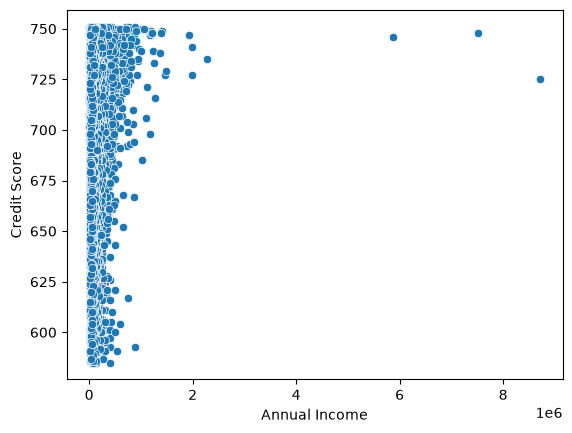

In [74]:
sns.scatterplot(
    data=df,
    x="Annual Income",
    y="Credit Score"
)
plt.show()

In [75]:
df.corr(numeric_only=True)["Annual Income"].sort_values(ascending=False)

Annual Income                1.000000
Monthly Debt                 0.471007
Current Loan Amount          0.352053
Current Credit Balance       0.305023
Years of Credit History      0.155108
Number of Open Accounts      0.145414
Tax Liens                    0.036209
Maximum Open Credit          0.031688
Credit Score                 0.014872
Number of Credit Problems   -0.017194
Bankruptcies                -0.047187
Name: Annual Income, dtype: float64

In [76]:
zero_inc = df['Annual Income'] == 0

In [77]:
print(zero_inc.sum())

1


In [78]:
df.loc[df['Annual Income'] == 0, 'Annual Income'] = np.nan

In [79]:
df.isnull().sum()[df.isnull().sum() > 0]

Current Loan Amount    35210
Credit Score           44498
Annual Income          44499
dtype: int64

In [80]:
print(df.groupby(df['Credit Score'].isna())['Loan Status']
        .value_counts(normalize=True).unstack())

Loan Status   Charged Off  Fully Paid
Credit Score                         
False            0.217404    0.782596
True             0.051441    0.948559


In [81]:
df = df.dropna(subset=['Credit Score', 'Annual Income'])
print(df.shape)

(171201, 19)


#### 2.4. 'Current Loan Amount' Variable

In [82]:
df = df[df['Current Loan Amount'].notna()].copy()
print(df.shape)

(135991, 19)


In [83]:
print(df['Loan Status'].value_counts(normalize=True))

Loan Status
Fully Paid     0.726313
Charged Off    0.273687
Name: proportion, dtype: float64


In [84]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 3. Feature Engineering

In [85]:
# Credit utilization: how much of the available credit limit is being used?
df['credit_utilization'] = (df['Current Credit Balance'] /
                            df['Maximum Open Credit'].replace(0, np.nan)).fillna(0).clip(upper=2)

# Debt-to-income ratio: what share of annual income goes to debt payments?
df['debt_to_income'] = (df['Monthly Debt'] * 12 / df['Annual Income']).clip(upper=2)

# Loan-to-income ratio: how large is the loan compared to annual income?
df['loan_to_income'] = (df['Current Loan Amount'] / df['Annual Income']).clip(upper=5)

# Are the new variables related to risk? (split into 5 equal groups and check the default rate)
for col in ['credit_utilization', 'debt_to_income', 'loan_to_income']:
    print(df.groupby(pd.qcut(df[col], 5, duplicates='drop'))['Loan Status']
            .apply(lambda s: (s == 'Charged Off').mean()).round(3), "\n")

credit_utilization
(-0.001, 0.322]    0.197
(0.322, 0.49]      0.253
(0.49, 0.632]      0.285
(0.632, 0.78]      0.305
(0.78, 1.525]      0.329
Name: Loan Status, dtype: float64 

debt_to_income
(-0.001, 0.0984]    0.198
(0.0984, 0.145]     0.228
(0.145, 0.189]      0.265
(0.189, 0.241]      0.306
(0.241, 0.592]      0.371
Name: Loan Status, dtype: float64 

loan_to_income
(-8.100000000000002e-05, 0.111]    0.191
(0.111, 0.17]                      0.213
(0.17, 0.233]                      0.249
(0.233, 0.317]                     0.312
(0.317, 1.127]                     0.403
Name: Loan Status, dtype: float64 



In [86]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Years in current job', 'Home Ownership',
       'Annual Income', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Number of Open Accounts', 'Number of Credit Problems',
       'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies',
       'Tax Liens', 'delinq_cat', 'credit_utilization', 'debt_to_income',
       'loan_to_income'],
      dtype='str')

In [87]:
df = df.drop(
    columns=["Loan ID", "Customer ID", "score_missing", "Income_CS_Missing"],
    errors="ignore"
)
df['Loan Status'] = (df['Loan Status'] == 'Charged Off').astype(int)
cat_cols = ['Term', 'Years in current job', 'Home Ownership', 'Purpose', 'delinq_cat']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [88]:
df.shape

(135991, 39)

### 4. Train and Test

In [89]:
X = df.drop(columns=['Loan Status'])
y = df['Loan Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(108792, 38) (27199, 38)
0.27368740348555043 0.27368653259311004


### 5. Result

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report)

modeller = {
    "LogisticRegression": Pipeline([("scaler", StandardScaler()),
                                    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))]),
    "GaussianNB": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                                           class_weight="balanced", n_jobs=-1, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
    "KNN": Pipeline([("scaler", StandardScaler()),
                 ("model", KNeighborsClassifier(n_neighbors=51, n_jobs=-1))]),
}

def algo_test(x_train, x_test, y_train, y_test):
    sonuc = []
    for isim, model in modeller.items():
        print(isim, "eğitiliyor...")
        model.fit(x_train, y_train)
        tahmin = model.predict(x_test)
        olasilik = model.predict_proba(x_test)[:, 1]
        sonuc.append({
            "Model": isim,
            "ROC AUC":   roc_auc_score(y_test, olasilik),
            "Recall":    recall_score(y_test, tahmin),
            "Precision": precision_score(y_test, tahmin),
            "F1":        f1_score(y_test, tahmin),
            "Accuracy":  accuracy_score(y_test, tahmin),
        })

    metrics = pd.DataFrame(sonuc).set_index("Model").sort_values("ROC AUC", ascending=False)

    en_iyi = metrics.index[0]
    print("\nEn başarılı model:", en_iyi)
    tahmin = modeller[en_iyi].predict(x_test)
    print(confusion_matrix(y_test, tahmin))
    print(classification_report(y_test, tahmin))

    return metrics.round(3)

algo_test(X_train, X_test, y_train, y_test)

LogisticRegression eğitiliyor...
GaussianNB eğitiliyor...
DecisionTree eğitiliyor...
RandomForest eğitiliyor...
AdaBoost eğitiliyor...
HistGradientBoosting eğitiliyor...
KNN eğitiliyor...

En başarılı model: HistGradientBoosting
[[12841  6914]
 [ 2538  4906]]
              precision    recall  f1-score   support

           0       0.83      0.65      0.73     19755
           1       0.42      0.66      0.51      7444

    accuracy                           0.65     27199
   macro avg       0.63      0.65      0.62     27199
weighted avg       0.72      0.65      0.67     27199



,ROC AUC,Recall,Precision,F1,Accuracy
Model,,,,,
HistGradientBoosting,0.712,0.659,0.415,0.509,0.652
RandomForest,0.712,0.627,0.427,0.508,0.667
AdaBoost,0.705,0.166,0.570,0.257,0.737
LogisticRegression,0.704,0.607,0.426,0.500,0.668
DecisionTree,0.691,0.646,0.399,0.494,0.637
KNN,0.677,0.110,0.577,0.185,0.734
GaussianNB,0.672,0.458,0.435,0.446,0.689


In [91]:
hgb = modeller["LogisticRegression"]
prob = hgb.predict_proba(X_test)[:, 1]

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    approve = prob < t
    rows.append({'Eşik': t,
                 'Onay oranı': approve.mean(),
                 'Onaylananlarda temerrüt': y_test[approve].mean(),
                 'Reddedilen riskli müşteri': (~approve & (y_test == 1)).sum() / (y_test == 1).sum()})
print(pd.DataFrame(rows).round(3))

   Eşik  Onay oranı  Onaylananlarda temerrüt  Reddedilen riskli müşteri
0   0.3       0.150                    0.093                      0.949
1   0.4       0.388                    0.137                      0.806
2   0.5       0.610                    0.176                      0.607
3   0.6       0.778                    0.212                      0.398
4   0.7       0.888                    0.237                      0.230


Credit Score                  0.0615
loan_to_income                0.0366
Purpose_Debt Consolidation    0.0325
Current Loan Amount           0.0134
Term_Short Term               0.0131
debt_to_income                0.0121
Purpose_Other                 0.0087
credit_utilization            0.0067
Purpose_Home Improvements     0.0062
Home Ownership_Rent           0.0061
dtype: float64


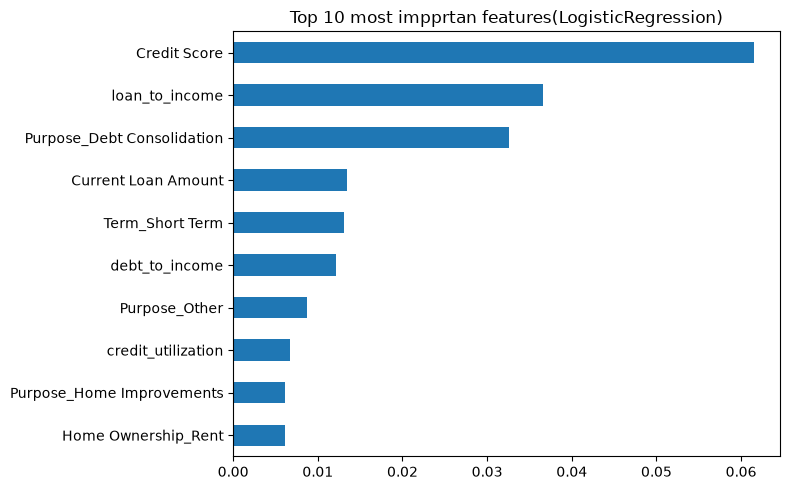

In [92]:
from sklearn.inspection import permutation_importance

lrg = modeller["LogisticRegression"]
sample = X_test.sample(5000, random_state=42)
imp = permutation_importance(lrg, sample, y_test.loc[sample.index],
                             scoring="roc_auc", n_repeats=5, random_state=42)

importance = pd.Series(imp.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(importance.head(10).round(4))

importance.head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top 10 most impprtan features(LogisticRegression)")
plt.tight_layout()
plt.show()

### 6. Conclusion

### 7. Questions